# NeuralMag skyrmion Ms comparison

This notebook mirrors a MuMax-style cylindrical setup and relaxes the same vortex-like seed twice while varying only the saturation magnetization `Ms`.

```text
setgridsize(64, 64, 20)
setcellsize(5e-9, 5e-9, 1e-9)
setgeom(cylinder(320e-9, 20e-9))
m = Vortex(1, -1)
A = 1.6e-11, Di = 4e-3, Ku = 510e3
Ms = 800e3 or 300e3
```

The output is just the two relaxed skyrmion states and a side-by-side visualization of their support and magnetization components.

In [25]:
from __future__ import annotations

from pathlib import Path
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

import optax
import jax.numpy as jnp
import jax

# NeuralMag's FEM field assembly uses SI cell volumes, so the mass matrix
# entries are tiny. Float32 can give NaN tangents when differentiating the
# effective field with respect to Ms through h / mass. This must happen before
# NeuralMag/JAX initializes its backend. Restart the kernel after changing it.
os.environ["JAX_ENABLE_X64"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.4"

from jax import config as jax_config

jax_config.update("jax_enable_x64", True)

cwd = Path.cwd().resolve()
repo_root = next((path for path in (cwd, *cwd.parents) if (path / "pyproject.toml").exists()), cwd)
for extra_path in (repo_root / "src", repo_root / "vendor/neuralmag"):
    if extra_path.exists() and str(extra_path) not in sys.path:
        sys.path.insert(0, str(extra_path))

try:
    import neuralmag as nm
except ImportError as exc:
    raise ImportError(
        "This notebook requires NeuralMag. Use the repo's notebook environment or "
        "install the vendored package/extras first."
    ) from exc

nm.config.dtype = "float64"

try:
    _ = nm.config.backend
    backend_name = getattr(getattr(nm, "config", None), "backend", None)
    backend_name = getattr(backend_name, "name", backend_name)
except Exception as exc:
    raise RuntimeError("NeuralMag needs a working backend before this notebook can run.") from exc

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["image.origin"] = "lower"
np.set_printoptions(precision=5, suppress=True)

print(f"NeuralMag backend: {backend_name}")

2026-04-27 16:44:32 NeuralMag:INFO [NeuralMag] Set default dtype to 'float64'.


NeuralMag backend: jax


In [31]:
# MuMax-like geometry and fixed material parameters.
nx, ny, nz = 64, 64, 20
cellsize_nm_xyz = np.array([5.0, 5.0, 1.0], dtype=np.float32)
diameter_nm = 320.0
thickness_nm = 20.0

material = dict(
    A_J_per_m=1e-11,
    Di_J_per_m2=0,
    Ku_J_per_m3=0,
    alpha=0.0,
)

skyrmion_cases = {
    "Ms 800e3 A/m": 800e3,
    "Ms 300e3 A/m": 300e3,
}

# LLG can be slow on CPU. Increase these when running on a GPU or when making final data.
llg_max_steps = 2048
llg_tol_1_per_s = 2e8
llg_dt_s = 2e-14
demag_p = 3

print(f"Grid: {(nx, ny, nz)}")
print(f"Cell size xyz: {cellsize_nm_xyz} nm")
print(f"Cylinder: {diameter_nm:g} nm diameter, {thickness_nm:g} nm thick")
print(f"A = {material['A_J_per_m']:.3g} J/m")
print(f"Di = {material['Di_J_per_m2']:.3g} J/m^2")
print(f"Ku = {material['Ku_J_per_m3']:.3g} J/m^3")
print("Ms cases:", ", ".join(f"{value:.3g} A/m" for value in skyrmion_cases.values()))

Grid: (64, 64, 20)
Cell size xyz: [5. 5. 1.] nm
Cylinder: 320 nm diameter, 20 nm thick
A = 1e-11 J/m
Di = 0 J/m^2
Ku = 0 J/m^3
Ms cases: 8e+05 A/m, 3e+05 A/m


In [32]:
def cell_centered_axes(nx: int, ny: int, nz: int, cellsize_nm_xyz: np.ndarray):
    sx, sy, sz = [float(v) for v in cellsize_nm_xyz]
    x = (np.arange(nx, dtype=np.float32) + 0.5) * sx - (nx * sx / 2.0)
    y = (np.arange(ny, dtype=np.float32) + 0.5) * sy - (ny * sy / 2.0)
    z = (np.arange(nz, dtype=np.float32) + 0.5) * sz - (nz * sz / 2.0)
    return np.meshgrid(x, y, z, indexing="ij")


def make_cylinder_support(nx: int, ny: int, nz: int, cellsize_nm_xyz: np.ndarray, diameter_nm: float, thickness_nm: float):
    xx, yy, zz = cell_centered_axes(nx, ny, nz, cellsize_nm_xyz)
    radius = diameter_nm / 2.0
    rho = ((xx * xx + yy * yy) <= radius * radius) & (np.abs(zz) <= thickness_nm / 2.0)
    return rho.astype(np.float32)


def normalize_on_support(m_xyz: np.ndarray, rho_xyz: np.ndarray, threshold: float = 0.5):
    norms = np.linalg.norm(m_xyz, axis=-1, keepdims=True)
    safe_norms = np.where(norms > 0.0, norms, 1.0)
    return np.where(rho_xyz[..., None] > threshold, m_xyz / safe_norms, 0.0).astype(np.float32)


def make_vortex_initial_state(
    rho_xyz: np.ndarray,
    cellsize_nm_xyz: np.ndarray,
    *,
    circulation: int = 1,
    polarization: int = -1,
    core_radius_nm: float = 18.0,
):
    xx, yy, _ = cell_centered_axes(*rho_xyz.shape, cellsize_nm_xyz)
    phi = np.arctan2(yy, xx)
    radius = np.sqrt(xx * xx + yy * yy)
    mz = polarization * np.exp(-(radius / core_radius_nm) ** 2)
    in_plane = np.sqrt(np.maximum(1.0 - mz * mz, 0.0))
    m = np.zeros(rho_xyz.shape + (3,), dtype=np.float32)
    m[..., 0] = -circulation * np.sin(phi) * in_plane
    m[..., 1] = circulation * np.cos(phi) * in_plane
    m[..., 2] = mz
    return normalize_on_support(m, rho_xyz)


def make_random_initial_state(
    rho_xyz: np.ndarray,
    *,
    seed: int = 4,
):
    rng = np.random.default_rng(seed)
    m = rng.normal(size=rho_xyz.shape + (3,)).astype(np.float32)
    return normalize_on_support(m, rho_xyz)


def cell_vectors_to_normalized_node_function(state, m_cell_xyz: np.ndarray, rho_cell_xyz: np.ndarray):
    rho_cf = nm.CellFunction(state, tensor=state.tensor(rho_cell_xyz, dtype=state.dtype))
    m_cf = nm.VectorCellFunction(state, tensor=state.tensor(m_cell_xyz, dtype=state.dtype))
    rho_node = np.asarray(rho_cf.to_node().tensor)
    m_node = np.asarray(m_cf.to_node().tensor)
    norms = np.linalg.norm(m_node, axis=-1, keepdims=True)
    safe_norms = np.where(norms > 0.0, norms, 1.0)
    m_node = np.where(rho_node[..., None] > 0.5, m_node / safe_norms, 0.0)
    return nm.VectorFunction(state, tensor=state.tensor(m_node, dtype=state.dtype))


def constant_vector_cell_function(state, shape_xyz: tuple[int, int, int], vector):
    values = np.broadcast_to(np.asarray(vector, dtype=np.float64), shape_xyz + (3,)).copy()
    return nm.VectorCellFunction(state, tensor=state.tensor(values, dtype=state.dtype))


def build_skyrmion_llg_state(rho_xyz: np.ndarray, m0_xyz: np.ndarray, Ms_A_per_m: float):
    state = nm.State(nm.Mesh(rho_xyz.shape, tuple((cellsize_nm_xyz * 1e-9).tolist())))
    rho_min = float(getattr(state, "eps", 1e-12))
    state.rho = nm.CellFunction(state, tensor=state.tensor(np.clip(rho_xyz, rho_min, 1.0), dtype=state.dtype))

    state.material.Ms = nm.CellFunction(state).fill(float(Ms_A_per_m))
    state.material.A = nm.CellFunction(state).fill(material["A_J_per_m"])

    state.material.Di = nm.CellFunction(state).fill(material["Di_J_per_m2"])

    state.material.Di_axis = constant_vector_cell_function(state, rho_xyz.shape, [0.0, 0.0, 1.0])
    state.material.Ku = nm.CellFunction(state).fill(material["Ku_J_per_m3"])

    state.material.Ku_axis = constant_vector_cell_function(state, rho_xyz.shape, [0.0, 0.0, 1.0])
    state.material.alpha = nm.CellFunction(state).fill(material["alpha"])


    state.m = cell_vectors_to_normalized_node_function(state, m0_xyz, rho_xyz)
    state.t = state.tensor(0.0)

    nm.ExchangeField().register(state, "exchange")
    nm.DemagField(p=demag_p).register(state, "demag")
    nm.InterfaceDMIField().register(state, "idmi")
    nm.UniaxialAnisotropyField().register(state, "uaniso")
    nm.TotalField("exchange", "demag", "idmi", "uaniso").register(state)
    return state


def relax_state_with_llg(state, *, max_steps: int, tol: float, dt: float):
    llg = nm.LLGSolver(state, max_steps=max_steps)
    llg.relax(tol=tol, dt=dt)
    return state, llg


rho_cell = make_cylinder_support(nx, ny, nz, cellsize_nm_xyz, diameter_nm, thickness_nm)
initial_magnetization_kind = "vortex"  # "random" or "vortex"
random_magnetization_seed = 4

vortex_m0_cell = make_vortex_initial_state(rho_cell, cellsize_nm_xyz, circulation=1, polarization=-1)
random_m0_cell = make_random_initial_state(rho_cell, seed=random_magnetization_seed)
if initial_magnetization_kind == "random":
    m0_cell = random_m0_cell
    m0_description = f"random seed {random_magnetization_seed}"
elif initial_magnetization_kind == "vortex":
    m0_cell = vortex_m0_cell
    m0_description = "vortex circulation +1, polarization -1"
else:
    raise ValueError("initial_magnetization_kind must be 'random' or 'vortex'")

print(f"Support voxels: {int(rho_cell.sum())}")
print(f"Initial magnetization: {m0_description}")
print(f"Initial |m| on support: {np.linalg.norm(m0_cell[rho_cell > 0.5], axis=-1).mean():.5f}")

Support voxels: 64560
Initial magnetization: vortex circulation +1, polarization -1
Initial |m| on support: 1.00000


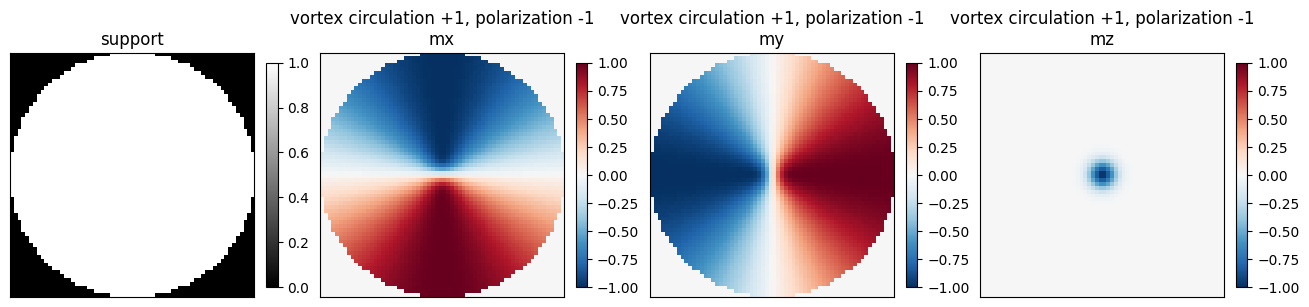

In [33]:
fig, axs = plt.subplots(1, 4, figsize=(13, 3.4), constrained_layout=True)
mid_z = nz // 2
for ax, image, title, cmap, vmin, vmax in [
    (axs[0], rho_cell[:, :, mid_z].T, "support", "gray", 0.0, 1.0),
    (axs[1], m0_cell[:, :, mid_z, 0].T, f"{m0_description}\nmx", "RdBu_r", -1.0, 1.0),
    (axs[2], m0_cell[:, :, mid_z, 1].T, f"{m0_description}\nmy", "RdBu_r", -1.0, 1.0),
    (axs[3], m0_cell[:, :, mid_z, 2].T, f"{m0_description}\nmz", "RdBu_r", -1.0, 1.0),
]:
    im = ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

In [35]:
results = {}
result_initial_m_cell = np.asarray(m0_cell, dtype=np.float32).copy()
result_initial_description = m0_description

for case_name, Ms_A_per_m in skyrmion_cases.items():
    print(f"Relaxing {case_name} from {result_initial_description} ...")
    started = time.perf_counter()
    state = build_skyrmion_llg_state(rho_cell, result_initial_m_cell, Ms_A_per_m)
    state, llg = relax_state_with_llg(
        state,
        max_steps=llg_max_steps,
        tol=llg_tol_1_per_s,
        dt=llg_dt_s,
    )
    elapsed_s = time.perf_counter() - started

    m_relaxed_cell = normalize_on_support(np.asarray(state.m.to_cell().tensor), rho_cell)
    rho_relaxed_cell = np.asarray(state.rho.tensor, dtype=np.float32)
    mean_m = m_relaxed_cell[rho_relaxed_cell > 0.5].mean(axis=0)
    results[case_name] = {
        "Ms_A_per_m": Ms_A_per_m,
        "state": state,
        "llg": llg,
        "rho": rho_relaxed_cell,
        "m": m_relaxed_cell,
        "m0": result_initial_m_cell,
        "m0_description": result_initial_description,
        "initial_magnetization_kind": initial_magnetization_kind,
        "random_magnetization_seed": random_magnetization_seed,
        "elapsed_s": elapsed_s,
        "mean_m": mean_m,
    }
    print(f"  elapsed {elapsed_s:.2f}s | mean m = {mean_m}")

print("done")

2026-04-27 16:55:24 NeuralMag:INFO [Mesh] 3D, 64 x 64 x 20 (size = 5e-09 x 5e-09 x 1e-09)
2026-04-27 16:55:24 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-27 16:55:24 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-04-27 16:55:24 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-27 16:55:24 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-27 16:55:24 NeuralMag:INFO [DemagField]: Set up demag tensor


Relaxing Ms 800e3 A/m from vortex circulation +1, polarization -1 ...


2026-04-27 16:55:26 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-04-27 16:55:26 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-04-27 16:55:26 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-27 16:55:26 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function
2026-04-27 16:55:30 NeuralMag:INFO [LLGSolverJAX] Relaxation started, initial energy E = 1.00738e-17 J
2026-04-27 16:55:39 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 3.89295e+10) 1/s
2026-04-27 16:55:50 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 3.88701e+10) 1/s
2026-04-27 16:55:50 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 3.88072e+10) 1/s
2026-04-27 16:55:50 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 3.87418e+10) 1/s
2026-04-27 16:55:50 NeuralMag

  elapsed 66.11s | mean m = [-0.       0.      -0.00225]
Relaxing Ms 300e3 A/m from vortex circulation +1, polarization -1 ...


2026-04-27 16:56:32 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-04-27 16:56:32 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-04-27 16:56:32 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-27 16:56:32 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function
2026-04-27 16:56:37 NeuralMag:INFO [LLGSolverJAX] Relaxation started, initial energy E = 5.29979e-18 J
2026-04-27 16:56:47 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 1.12363e+10) 1/s
2026-04-27 16:56:58 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 1.11089e+10) 1/s
2026-04-27 16:56:58 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 1.09806e+10) 1/s
2026-04-27 16:56:58 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 1.08546e+10) 1/s
2026-04-27 16:56:58 NeuralMag

  elapsed 68.72s | mean m = [ 0.       0.      -0.01854]
done


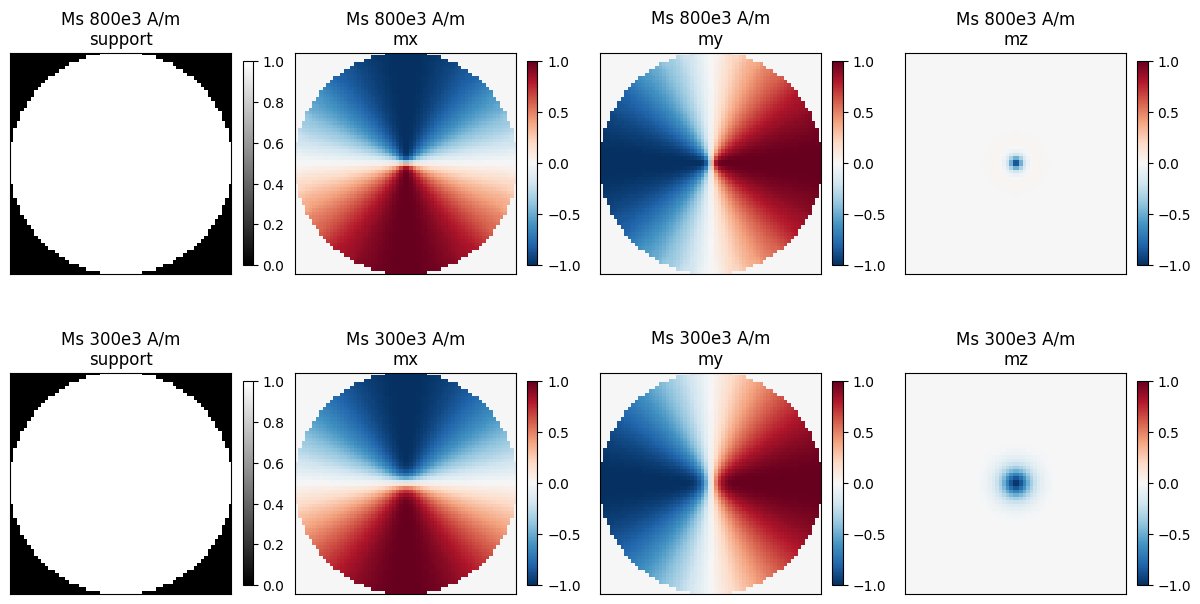

Ms 800e3 A/m: Ms = 8e+05 A/m | elapsed = 66.11 s | mean m = [-0.       0.      -0.00225]
Ms 300e3 A/m: Ms = 3e+05 A/m | elapsed = 68.72 s | mean m = [ 0.       0.      -0.01854]


In [36]:
n_cases = len(results)
fig, axs = plt.subplots(n_cases, 4, figsize=(12, 3.2 * n_cases), constrained_layout=True)
if n_cases == 1:
    axs = np.asarray([axs])

for row, (case_name, result) in enumerate(results.items()):
    rho = result["rho"]
    m = result["m"]
    mid = rho.shape[2] // 2
    panels = [
        (rho[:, :, mid].T, "support", "gray", 0.0, 1.0),
        (m[:, :, mid, 0].T, "mx", "RdBu_r", -1.0, 1.0),
        (m[:, :, mid, 1].T, "my", "RdBu_r", -1.0, 1.0),
        (m[:, :, mid, 2].T, "mz", "RdBu_r", -1.0, 1.0),
    ]
    for col, (image, title, cmap, vmin, vmax) in enumerate(panels):
        im = axs[row, col].imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
        axs[row, col].set_title(f"{case_name}\n{title}")
        axs[row, col].set_xticks([])
        axs[row, col].set_yticks([])
        plt.colorbar(im, ax=axs[row, col], fraction=0.046)
plt.show()

for case_name, result in results.items():
    print(
        f"{case_name}: Ms = {result['Ms_A_per_m']:.3g} A/m | "
        f"elapsed = {result['elapsed_s']:.2f} s | mean m = {result['mean_m']}"
    )

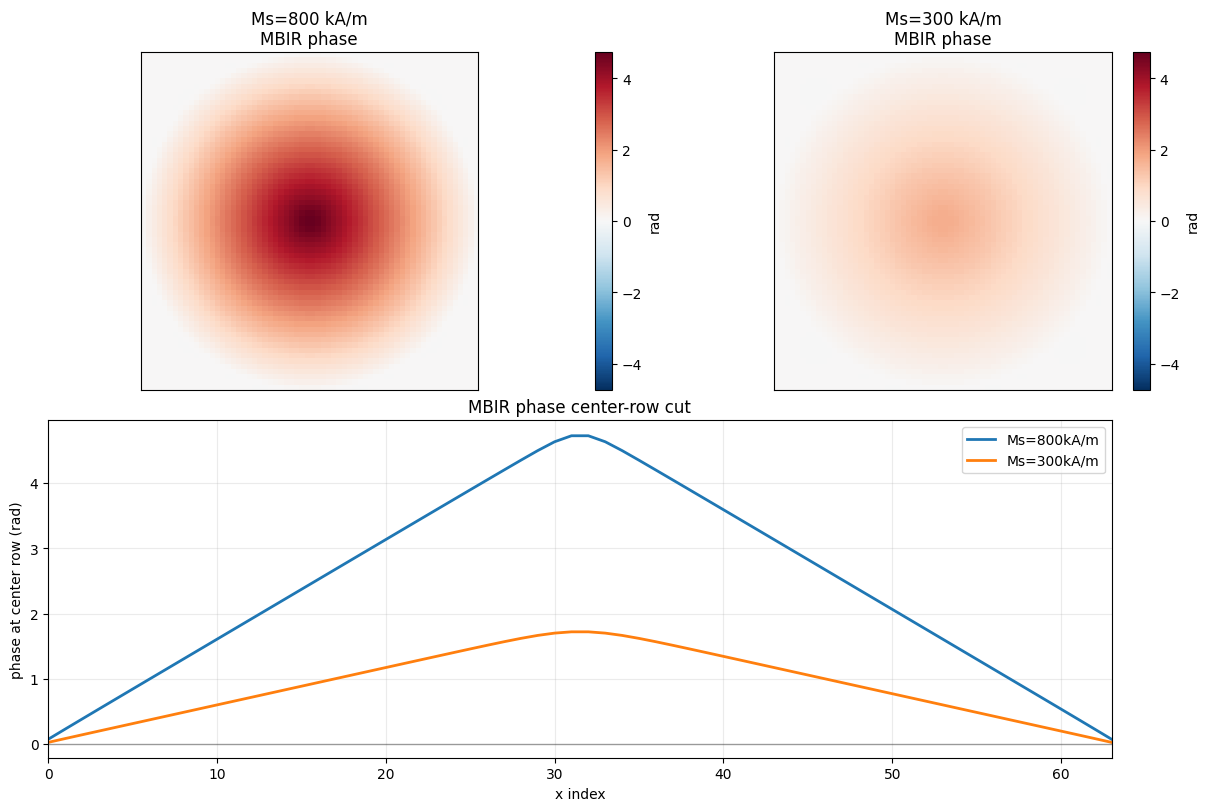

In [37]:
import unxt as u
from libertem_holo.base.mbir import MU_0, build_rdfc_kernel, forward_phase_from_density_and_magnetization


def xyz_to_zyx(values: np.ndarray):
    axes = (2, 1, 0) if values.ndim == 3 else (2, 1, 0, 3)
    return np.transpose(np.asarray(values), axes)


def mbir_phase_image_from_xyz(
    rho_xyz: np.ndarray,
    m_xyz: np.ndarray,
    cellsize_nm_xyz: np.ndarray,
    Ms_A_per_m: float,
):
    pixel_nm = float(cellsize_nm_xyz[0])
    path_step_nm = float(cellsize_nm_xyz[2])
    rho_zyx = xyz_to_zyx(rho_xyz.astype(np.float32))
    field_scale_t = float(np.asarray(MU_0.value)) * float(Ms_A_per_m)
    m_zyx_base = xyz_to_zyx(m_xyz.astype(np.float32)) * field_scale_t
    rdfc_kernel = build_rdfc_kernel((rho_zyx.shape[1], rho_zyx.shape[2]), geometry="disc")

    phase = forward_phase_from_density_and_magnetization(
        rho=rho_zyx,
        magnetization_3d=m_zyx_base,
        pixel_size=u.Quantity(pixel_nm, "nm"),
        projection_step_size=u.Quantity(path_step_nm, "nm"),
        axis="z",
        geometry="disc",
        rdfc_kernel=rdfc_kernel,
        )
    return np.asarray(phase, dtype=np.float32)


def phase_center_row_cut(phase_yx: np.ndarray):
    center_row = phase_yx.shape[0] // 2
    return phase_yx[center_row, :]


phase_results = []
for case_name, result in results.items():
    phase_yx = mbir_phase_image_from_xyz(
        result["rho"],
        result["m"],
        cellsize_nm_xyz,
        result["Ms_A_per_m"],
    )
    result["phase_yx"] = phase_yx
    phase_results.append((case_name, result))

x_index = np.arange(nx)
fig = plt.figure(figsize=(12, 8), constrained_layout=True)
gs = fig.add_gridspec(2, len(phase_results))

all_phase_values = np.concatenate([result["phase_yx"].ravel() for _, result in phase_results])
phase_lim = max(abs(float(all_phase_values.min())), abs(float(all_phase_values.max())), 1e-12)

for col, (case_name, result) in enumerate(phase_results):
    ax = fig.add_subplot(gs[0, col])
    ms_ka_per_m = result["Ms_A_per_m"] / 1e3
    phase_yx = result["phase_yx"]
    im = ax.imshow(phase_yx, cmap="RdBu_r", vmin=-phase_lim, vmax=phase_lim)
    ax.set_title(f"Ms={ms_ka_per_m:.0f} kA/m\nMBIR phase")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, label="rad")

ax = fig.add_subplot(gs[1, :])
for case_name, result in phase_results:
    profile = phase_center_row_cut(result["phase_yx"])
    ms_ka_per_m = result["Ms_A_per_m"] / 1e3
    ax.plot(x_index, profile, linewidth=2.0, label=f"Ms={ms_ka_per_m:.0f}kA/m")

ax.set_title("MBIR phase center-row cut")
ax.set_xlabel("x index")
ax.set_ylabel("phase at center row (rad)")
ax.set_xlim(0, nx - 1)
ax.axhline(0.0, color="k", linewidth=1.0, alpha=0.35)
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

## Differentiable NeuralMag LLG solver

NeuralMag already owns the Diffrax integration path. For the JAX backend, `nm.LLGSolver(state, parameters=[...])` resolves NeuralMag's registered effective field, builds the Diffrax term internally, and exposes `solve(t, *args)` for differentiable time-dependent optimization.

So the clean path is:

`Msat -> nm.LLGSolver(..., parameters=["material__Ms"]).solve(...) -> NeuralMag node-to-cell projection -> MBIR phase loss`

This still requires NeuralMag's optional JAX LLG dependencies (`diffrax`, `lineax`, and `optimistix`). It also needs JAX x64 enabled before NeuralMag initializes: with SI cell volumes the generated FEM field code divides by very small mass-matrix entries, and float32 underflows in the derivative of that division when differentiating with respect to `Ms`.

For scalar material fits the simplest useful derivative is reverse mode via `jax.value_and_grad(...)`. The objective below uses NeuralMag's public `LLGSolver.solve(...)` API with a fixed Diffrax step size; this keeps the gradient smoother than the adaptive controller while preserving the clean NeuralMag-owned LLG path.


In [38]:
import diffrax as dfx
import importlib

# Pick the same synthetic target as the compact PoC above.
neuralmag_solver_fit_case_name = "Ms 800e3 A/m"
neuralmag_solver_fit_result = results[neuralmag_solver_fit_case_name]
if "m0" not in neuralmag_solver_fit_result:
    raise RuntimeError("Rerun the target-relaxation cell above; existing results do not store their initial magnetization.")
fit_input_m_cell = np.asarray(neuralmag_solver_fit_result["m0"], dtype=np.float32)
fit_input_description = neuralmag_solver_fit_result["m0_description"]
fit_start_delta = float(np.max(np.abs(fit_input_m_cell - np.asarray(m0_cell, dtype=np.float32))))

print(f"Fitting target: {neuralmag_solver_fit_case_name}")
print(f"Solver start:   {fit_input_description}")
if fit_start_delta > 1e-6:
    print("Note: current m0_cell differs from the target stored start; using the target stored start for the fit.")

# Build a fresh NeuralMag state from the selected starting magnetization.
# The registered NeuralMag field terms define state.h; LLGSolver resolves that machinery internally.
neuralmag_solver_state = build_skyrmion_llg_state(
    rho_cell,
    fit_input_m_cell,
    Ms_A_per_m=neuralmag_solver_fit_result["Ms_A_per_m"],
)
# LLGSolver.solve feeds alpha straight into llg_rhs with nodal m. A cell alpha
# field has shape (64, 64, 20), while nodal m has shape (65, 65, 21, 3), so use
# a scalar alpha here. Also avoid alpha=0 for this differentiable probe; pure
# precession has a fragile adaptive-ODE sensitivity, while nonzero damping is
# the relaxation-relevant path.
solver_alpha = 0.1 if float(material["alpha"]) == 0.0 else float(material["alpha"])
neuralmag_solver_state.material.alpha = neuralmag_solver_state.tensor(solver_alpha)

# Refresh the local JAX LLG backend so this notebook picks up the optional
# solve(dt0=..., stepsize_controller=..., adjoint=...) controls without a restart.
import neuralmag.backends.jax.llg_solver_jax as llg_solver_jax
llg_solver_jax = importlib.reload(llg_solver_jax)
nm.config.backend.LLGSolver = llg_solver_jax.LLGSolverJAX

neuralmag_solver = nm.LLGSolver(
    neuralmag_solver_state,
    parameters=["material__Ms"],
    max_steps=llg_max_steps,
)

# The solver returns nodal m. Use NeuralMag's own generated node-to-cell projection
# before passing the field to the MBIR phase model.
solver_node_to_cell = neuralmag_solver_state.resolve(neuralmag_solver_state.m._code.to_cell, ["f"])

solver_dtype = neuralmag_solver_state.dtype
mu0_solver = jnp.asarray(MU_0.value, dtype=solver_dtype)
rho_solver_xyz = jnp.asarray(neuralmag_solver_fit_result["rho"], dtype=solver_dtype)
rho_solver_zyx = jnp.transpose(rho_solver_xyz, (2, 1, 0))
support_solver = rho_solver_xyz > 0.5
rdfc_solver_kernel = build_rdfc_kernel((rho_solver_zyx.shape[1], rho_solver_zyx.shape[2]), geometry="disc", dtype=solver_dtype)
target_phase_solver = jnp.asarray(
    neuralmag_solver_fit_result.get(
        "phase_yx",
        mbir_phase_image_from_xyz(
            neuralmag_solver_fit_result["rho"],
            neuralmag_solver_fit_result["m"],
            cellsize_nm_xyz,
            neuralmag_solver_fit_result["Ms_A_per_m"],
        ),
    ),
    dtype=solver_dtype,
)

# Keep the differentiable probe deliberately short so compile/run times stay reasonable.
# Fixed steps make the parameter gradient much smoother than an adaptive controller
# for this tiny scalar fit.
solver_times = neuralmag_solver_state.tensor([0.0, 2e-14])
llg_dt0 = neuralmag_solver_state.tensor(2e-15)
llg_stepsize_controller = dfx.ConstantStepSize()
llg_adjoint = dfx.DirectAdjoint()
msat_min = 2e5
msat_max = 1.0e6


def _bounded_msat(theta):
    return msat_min + (msat_max - msat_min) * jax.nn.sigmoid(theta)


def _ms_solver_field(msat_a_per_m):
    return jnp.ones(rho_solver_xyz.shape, dtype=solver_dtype) * msat_a_per_m


def _normalize_solver_cell_m(m_cell_xyz):
    mask = support_solver.astype(m_cell_xyz.dtype)[..., None]
    norm = jnp.sqrt(jnp.sum(m_cell_xyz * m_cell_xyz, axis=-1, keepdims=True) + jnp.finfo(m_cell_xyz.dtype).eps**2)
    return mask * m_cell_xyz / norm


def _phase_from_solver_node_m(m_node, msat_a_per_m):
    m_cell_xyz = _normalize_solver_cell_m(solver_node_to_cell(m_node))
    m_zyx = jnp.transpose(m_cell_xyz, (2, 1, 0, 3))
    m_zyx = m_zyx * (mu0_solver * msat_a_per_m)
    return forward_phase_from_density_and_magnetization(
        rho=rho_solver_zyx,
        magnetization_3d=m_zyx,
        projection_step_size=u.Quantity(float(cellsize_nm_xyz[2]), "nm"),
        pixel_size=u.Quantity(float(cellsize_nm_xyz[0]), "nm"),
        axis="z",
        geometry="disc",
        rdfc_kernel=rdfc_solver_kernel,
    )



def neuralmag_solver_phase_loss(theta):
    msat = _bounded_msat(theta)
    sol = neuralmag_solver.solve(
        solver_times,
        _ms_solver_field(msat),
    )
    phase_pred = _phase_from_solver_node_m(sol.ys[-1], msat)
    residual = phase_pred - target_phase_solver
    loss = 0.5 * jnp.mean(residual * residual)
    aux = {
        "msat": msat,
        "phase_rms": jnp.sqrt(jnp.mean(residual * residual)),
        "phase_pred": phase_pred,
        "m_node_final": sol.ys[-1],
    }
    return loss, aux

2026-04-27 16:57:43 NeuralMag:INFO [Mesh] 3D, 64 x 64 x 20 (size = 5e-09 x 5e-09 x 1e-09)
2026-04-27 16:57:43 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-27 16:57:43 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-04-27 16:57:43 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-27 16:57:43 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-27 16:57:43 NeuralMag:INFO [DemagField]: Set up demag tensor


Fitting target: Ms 800e3 A/m
Solver start:   vortex circulation +1, polarization -1


2026-04-27 16:57:45 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-04-27 16:57:45 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-04-27 16:57:45 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-27 16:57:45 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function


In [39]:
# run_neuralmag_solver_optimizer = True
# llg_solver_optimizer_steps = 200

# optimizer = optax.adam(learning_rate=0.03)
# theta = jnp.asarray(0.0, dtype=solver_dtype)
# opt_state = optimizer.init(theta)
# solver_history = []

# llg_value_and_grad = jax.jit(jax.value_and_grad(neuralmag_solver_phase_loss, has_aux=True))

# for step in range(llg_solver_optimizer_steps):
#     print(f"Optimizer step {step} ...")
#     (loss_val, aux), grad = llg_value_and_grad(theta)
#     loss_val.block_until_ready()
#     row = {
#         "step": step,
#         "msat": float(aux["msat"]),
#         "loss": float(loss_val),
#         "phase_rms": float(aux["phase_rms"]),
#         "grad": float(grad),
#     }
#     solver_history.append(row)
#     if not np.isfinite(row["loss"]) or not np.isfinite(row["grad"]):
#         print("Stopping early after non-finite optimizer value:", row)
#         break
#     updates, opt_state = optimizer.update(grad, opt_state, theta)
#     theta = optax.apply_updates(theta, updates)

# print(solver_history[-1])

# steps = np.array([row["step"] for row in solver_history])
# ms_hist = np.array([row["msat"] for row in solver_history])
# rms_hist = np.array([row["phase_rms"] for row in solver_history])

# fig, axs = plt.subplots(1, 2, figsize=(8, 3.4), constrained_layout=True)
# axs[0].plot(steps, ms_hist, marker="o")
# axs[0].axhline(neuralmag_solver_fit_result["Ms_A_per_m"], color="k", ls="--", lw=1.0)
# axs[0].set_title("NeuralMag LLGSolver Msat")
# axs[0].set_xlabel("step")
# axs[0].set_ylabel("A/m")
# axs[0].grid(True, alpha=0.25)

# axs[1].plot(steps, rms_hist, marker="o")
# axs[1].set_title("Phase RMS")
# axs[1].set_xlabel("step")
# axs[1].set_ylabel("rad")
# axs[1].grid(True, alpha=0.25)
# plt.show()


## LLG versus NeuralMag BB steepest descent

This section keeps both inner physics solvers differentiable and compares the outer `Msat` fit convergence. The LLG branch goes through NeuralMag's `LLGSolver`/Diffrax machinery. The steepest-descent branch now uses NeuralMag's own `EnergyMinimizer`, the same BB/Cayley driver used by the standard-problem demos, via its differentiable fixed-step `solve_fixed(...)` path.

In [40]:
comparison_outer_steps = 300
comparison_learning_rate = 0.03

# Match NeuralMag's standard-problem BB/Cayley defaults. The convergence
# metric has effective-field units, so 1e3 is already a tight static-relaxation
# tolerance; 1e-3 tends to drive the BB loop into the safety cap.
bb_fit_mode = "dynamic_jvp"  # "dynamic_jvp" uses convergence; "fixed_jvp" uses a fixed scan.
bb_tol = 1e3
bb_max_iter = 2000
bb_tau_min = 1e-18
bb_tau_max = 1e-4
bb_project_each_step = False
bb_diagnostic_inner_steps = min(512, bb_max_iter)
run_solver_method_comparison = True
run_bb_inner_convergence_diagnostic = False

if comparison_learning_rate == 0.0:
    print("Warning: comparison_learning_rate is zero, so the outer material fit will not move.")

comparison_target_msat = float(neuralmag_solver_fit_result["Ms_A_per_m"])
comparison_target_m_cell = jnp.asarray(neuralmag_solver_fit_result["m"], dtype=solver_dtype)
comparison_input_m_cell = jnp.asarray(fit_input_m_cell, dtype=solver_dtype)
comparison_target_phase = jnp.asarray(target_phase_solver, dtype=solver_dtype)
comparison_initial_label = fit_input_description
comparison_input_m_node = jnp.asarray(neuralmag_solver_state.m.tensor, dtype=solver_dtype)
rho_solver_node = jnp.asarray(neuralmag_solver_state.rho.to_node().tensor, dtype=solver_dtype)
support_solver_node = rho_solver_node > 0.5


def _normalize_solver_node_m(m_node_xyz):
    mask = support_solver_node.astype(m_node_xyz.dtype)[..., None]
    norm = jnp.sqrt(jnp.sum(m_node_xyz * m_node_xyz, axis=-1, keepdims=True) + jnp.finfo(m_node_xyz.dtype).eps**2)
    return mask * m_node_xyz / norm


def comparison_phase_from_cell_m(m_cell_xyz, msat_a_per_m):
    m_cell_xyz = _normalize_solver_cell_m(m_cell_xyz)
    m_zyx = jnp.transpose(m_cell_xyz, (2, 1, 0, 3))
    m_zyx = m_zyx * (mu0_solver * msat_a_per_m)
    return forward_phase_from_density_and_magnetization(
        rho=rho_solver_zyx,
        magnetization_3d=m_zyx,
        projection_step_size=u.Quantity(float(cellsize_nm_xyz[2]), "nm"),
        pixel_size=u.Quantity(float(cellsize_nm_xyz[0]), "nm"),
        axis="z",
        geometry="disc",
        rdfc_kernel=rdfc_solver_kernel,
    )


def comparison_cell_m_from_node_m(m_node_xyz):
    return _normalize_solver_cell_m(solver_node_to_cell(_normalize_solver_node_m(m_node_xyz)))


def comparison_phase_from_node_m(m_node_xyz, msat_a_per_m):
    return comparison_phase_from_cell_m(comparison_cell_m_from_node_m(m_node_xyz), msat_a_per_m)


comparison_input_phase = comparison_phase_from_cell_m(comparison_input_m_cell, comparison_target_msat)

# Nodal state for the BB branch, matching NeuralMag's standard-problem BB path.
# The MBIR phase comparison still projects the final nodal magnetization to cells.
sd_state = nm.State(nm.Mesh(tuple(rho_solver_xyz.shape), tuple((cellsize_nm_xyz * 1e-9).tolist())))
sd_rho_np = np.clip(np.asarray(rho_solver_xyz, dtype=np.float64), float(getattr(sd_state, "eps", 1e-12)), 1.0)
sd_state.rho = nm.CellFunction(sd_state, tensor=sd_state.tensor(sd_rho_np, dtype=sd_state.dtype))
sd_state.material.Ms = nm.CellFunction(sd_state).fill(comparison_target_msat)
sd_state.material.A = nm.CellFunction(sd_state).fill(material["A_J_per_m"])
sd_state.material.Di = nm.CellFunction(sd_state).fill(material["Di_J_per_m2"])
sd_state.material.Di_axis = constant_vector_cell_function(sd_state, tuple(rho_solver_xyz.shape), [0.0, 0.0, 1.0])
sd_state.material.Ku = nm.CellFunction(sd_state).fill(material["Ku_J_per_m3"])
sd_state.material.Ku_axis = constant_vector_cell_function(sd_state, tuple(rho_solver_xyz.shape), [0.0, 0.0, 1.0])
sd_state.material.alpha = sd_state.tensor(0.0)
sd_state.m = nm.VectorFunction(sd_state, tensor=sd_state.tensor(np.asarray(neuralmag_solver_state.m.tensor, dtype=np.float64), dtype=sd_state.dtype))
nm.ExchangeField().register(sd_state, "exchange")
nm.DemagField(p=demag_p).register(sd_state, "demag")
nm.InterfaceDMIField().register(sd_state, "idmi")
nm.UniaxialAnisotropyField().register(sd_state, "uaniso")
nm.TotalField("exchange", "demag", "idmi", "uaniso").register(sd_state)

# This is the same NeuralMag BB/Cayley minimizer used by standard-problem-3.
# `parameters=["material__Ms"]` makes the runtime Ms field a differentiable
# argument. The fit path uses convergence-stopped `solve(...)` plus forward-mode
# JVP for the scalar material parameter; `solve_fixed(...)` is only used for the
# optional inner-step diagnostic history.
def _make_parameterized_bb_minimizer(state):
    kwargs = dict(
        method="alternating",
        update="cayley",
        tau_min=bb_tau_min,
        tau_max=bb_tau_max,
        tol=bb_tol,
        max_iter=bb_max_iter,
        projection=_normalize_solver_node_m if bb_project_each_step else None,
        parameters=["material__Ms"],
    )
    return nm.EnergyMinimizer(state, **kwargs)


sd_minimizer = _make_parameterized_bb_minimizer(sd_state)


def _bb_relax_for_fit(msat):
    return sd_minimizer.solve(
        comparison_input_m_node,
        _ms_solver_field(msat),
        tol=bb_tol,
        max_iter=bb_max_iter,
        return_info=True,
    )


def _bb_relax_for_loss(msat):
    return sd_minimizer.solve(
        comparison_input_m_node,
        _ms_solver_field(msat),
        tol=bb_tol,
        max_iter=bb_max_iter,
        return_info=False,
    )


@jax.jit
def steepest_descent_phase_loss(theta):
    msat = _bounded_msat(theta)
    m_final_node, inner_info = _bb_relax_for_fit(msat)
    m_final = comparison_cell_m_from_node_m(m_final_node)
    phase_pred = comparison_phase_from_cell_m(m_final, msat)
    residual = phase_pred - comparison_target_phase
    loss = 0.5 * jnp.mean(residual * residual)
    aux = {
        "msat": msat,
        "phase_rms": jnp.sqrt(jnp.mean(residual * residual)),
        "phase_pred": phase_pred,
        "m_cell_final": m_final,
        "inner_converged": inner_info["converged"],
        "inner_n_iter": inner_info["n_iter"],
        "inner_max_g_last": inner_info["max_g"],
    }
    return loss, aux


@jax.jit
def steepest_descent_scalar_phase_loss(theta):
    msat = _bounded_msat(theta)
    m_final_node, inner_info = _bb_relax_for_fit(msat)
    m_final = comparison_cell_m_from_node_m(m_final_node)
    phase_pred = comparison_phase_from_cell_m(m_final, msat)
    residual = phase_pred - comparison_target_phase
    loss = 0.5 * jnp.mean(residual * residual)
    aux = {
        "msat": msat,
        "phase_rms": jnp.sqrt(jnp.mean(residual * residual)),
        "inner_converged": inner_info["converged"],
        "inner_n_iter": inner_info["n_iter"],
        "inner_max_g_last": inner_info["max_g"],
    }
    return loss, aux


@jax.jit
def steepest_descent_loss_only(theta):
    msat = _bounded_msat(theta)
    m_final_node = _bb_relax_for_loss(msat)
    m_final = comparison_cell_m_from_node_m(m_final_node)
    phase_pred = comparison_phase_from_cell_m(m_final, msat)
    residual = phase_pred - comparison_target_phase
    return 0.5 * jnp.mean(residual * residual)


@jax.jit
def steepest_descent_phase_loss_with_info(theta):
    msat = _bounded_msat(theta)
    m_final_node, inner_info = sd_minimizer.solve_fixed(
        comparison_input_m_node,
        _ms_solver_field(msat),
        steps=bb_diagnostic_inner_steps,
        return_info=True,
    )
    m_final = comparison_cell_m_from_node_m(m_final_node)
    phase_pred = comparison_phase_from_cell_m(m_final, msat)
    residual = phase_pred - comparison_target_phase
    loss = 0.5 * jnp.mean(residual * residual)
    inner_max_g = inner_info["history"]["max_g"]
    inner_tau = inner_info["history"]["tau"]
    aux = {
        "msat": msat,
        "phase_rms": jnp.sqrt(jnp.mean(residual * residual)),
        "phase_pred": phase_pred,
        "m_cell_final": m_final,
        "inner_converged": inner_info["converged"],
        "inner_n_iter": inner_info["n_iter"],
        "inner_max_g_first": inner_max_g[0],
        "inner_max_g_last": inner_max_g[-1],
        "inner_max_g_min": jnp.min(inner_max_g),
        "inner_tau_first": inner_tau[0],
        "inner_tau_last": inner_tau[-1],
        "inner_tau_min": jnp.min(inner_tau),
        "inner_tau_max": jnp.max(inner_tau),
    }
    return loss, aux


llg_value_and_grad = jax.value_and_grad(neuralmag_solver_phase_loss, has_aux=True)


def llg_loss_grad_aux(theta):
    (loss_value, aux_value), grad_value = llg_value_and_grad(theta)
    return loss_value, grad_value, {
        "msat": aux_value["msat"],
        "phase_rms": aux_value["phase_rms"],
    }


def llg_final_aux(theta):
    _, aux_value = neuralmag_solver_phase_loss(theta)
    return {
        **aux_value,
        "m_cell_final": _normalize_solver_cell_m(solver_node_to_cell(aux_value["m_node_final"])),
    }


llg_loss_grad_aux_jit = jax.jit(llg_loss_grad_aux)
llg_final_aux_jit = jax.jit(llg_final_aux)


def sd_loss_grad_aux(theta):
    # The BB fit has one scalar material parameter, so forward-mode JVP avoids
    # the large reverse-mode tape for the inner magnetization relaxation. Keep
    # the differentiated path scalar-only; full fields and BB diagnostics are
    # computed once by `sd_final_aux_jit` for plotting.
    loss_value, grad_value = jax.jvp(
        steepest_descent_loss_only,
        (theta,),
        (jnp.ones_like(theta),),
    )
    msat = _bounded_msat(theta)
    return loss_value, grad_value, {
        "msat": msat,
        "phase_rms": jnp.sqrt(2.0 * loss_value),
    }


sd_loss_grad_aux_jit = jax.jit(sd_loss_grad_aux)
sd_final_aux_jit = jax.jit(lambda theta: steepest_descent_phase_loss(theta)[1])


def run_scalar_msat_fit(label, step_fn, final_aux_fn, *, outer_steps, learning_rate):
    theta = jnp.asarray(0.0, dtype=solver_dtype)
    optimizer = optax.adam(learning_rate=learning_rate)
    opt_state = optimizer.init(theta)

    compile_start = time.perf_counter()
    warm_loss, _, _ = step_fn(theta)
    warm_loss.block_until_ready()
    compile_elapsed_s = time.perf_counter() - compile_start

    rows = []
    run_start = time.perf_counter()
    for step in range(outer_steps + 1):
        print(f"Optimizer step {step} ...")
        loss_value, grad_value, aux_value = step_fn(theta)
        loss_value.block_until_ready()
        row = {
            "step": step,
            "msat": float(aux_value["msat"]),
            "loss": float(loss_value),
            "phase_rms": float(aux_value["phase_rms"]),
            "grad": float(grad_value),
            "elapsed_s": time.perf_counter() - run_start,
        }
        for key in (
            "inner_converged",
            "inner_n_iter",
            "inner_max_g_first",
            "inner_max_g_last",
            "inner_max_g_min",
            "inner_tau_first",
            "inner_tau_last",
            "inner_tau_min",
            "inner_tau_max",
        ):
            if key in aux_value:
                value = aux_value[key]
                row[key] = bool(value) if key == "inner_converged" else float(value)
        rows.append(row)
        if step < outer_steps:
            updates, opt_state = optimizer.update(grad_value, opt_state, theta)
            theta = optax.apply_updates(theta, updates)

    final_loss, _, _ = step_fn(theta)
    final_loss.block_until_ready()
    final_aux = final_aux_fn(theta)
    final_aux["phase_rms"].block_until_ready()
    return {
        "label": label,
        "compile_elapsed_s": compile_elapsed_s,
        "history": rows,
        "theta": theta,
        "msat": final_aux["msat"],
        "loss": final_loss,
        "phase_rms": final_aux["phase_rms"],
        "phase_pred": final_aux["phase_pred"],
        "m_cell_final": final_aux["m_cell_final"],
        "aux": final_aux,
    }


@jax.jit
def bb_inner_convergence_probe(theta):
    msat = _bounded_msat(theta)
    m_final_node, inner_info = sd_minimizer.solve_fixed(
        comparison_input_m_node,
        _ms_solver_field(msat),
        steps=bb_diagnostic_inner_steps,
        return_info=True,
    )
    m_final = comparison_cell_m_from_node_m(m_final_node)
    phase_pred = comparison_phase_from_cell_m(m_final, msat)
    residual = phase_pred - comparison_target_phase
    return {
        "msat": msat,
        "phase_rms": jnp.sqrt(jnp.mean(residual * residual)),
        "max_g_history": inner_info["history"]["max_g"],
        "tau_history": inner_info["history"]["tau"],
        "converged": inner_info["converged"],
        "m_cell_final": m_final,
    }


method_comparison_results = {}
if run_solver_method_comparison:
    print("Running solver method comparison ...")
    print(f"Comparison start: {comparison_initial_label}")
    print(f"BB project each step: {bb_project_each_step}")
    print(f"Running LLG fit for {comparison_outer_steps} steps with learning rate {comparison_learning_rate} ...")
    method_comparison_results["LLG"] = run_scalar_msat_fit(
        "LLG",
        llg_loss_grad_aux_jit,
        llg_final_aux_jit,
        outer_steps=comparison_outer_steps,
        learning_rate=comparison_learning_rate,
    )
    print(f"Running NeuralMag BB fit for {comparison_outer_steps} steps with learning rate {comparison_learning_rate} ...")
    method_comparison_results["NeuralMag BB"] = run_scalar_msat_fit(
        "NeuralMag BB",
        sd_loss_grad_aux_jit,
        sd_final_aux_jit,
        outer_steps=comparison_outer_steps,
        learning_rate=comparison_learning_rate,
    )

    for label, result in method_comparison_results.items():
        extra = ""
        aux = result.get("aux", {})
        if "inner_n_iter" in aux:
            extra = (
                f", inner steps={int(aux['inner_n_iter'])}, "
                f"inner max_g={float(aux['inner_max_g_last']):.3g}, "
                f"inner converged={bool(aux['inner_converged'])}"
            )
        print(
            f"{label}: final Msat={float(result['msat']):.1f} A/m, "
            f"phase RMS={float(result['phase_rms']):.6g} rad, "
            f"compile/warmup={result['compile_elapsed_s']:.2f}s, "
            f"optimizer={result['history'][-1]['elapsed_s']:.2f}s"
            f"{extra}"
        )


2026-04-27 16:57:45 NeuralMag:INFO [Mesh] 3D, 64 x 64 x 20 (size = 5e-09 x 5e-09 x 1e-09)
2026-04-27 16:57:45 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-27 16:57:45 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-04-27 16:57:45 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-27 16:57:45 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-27 16:57:45 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-27 16:57:47 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-04-27 16:57:47 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-04-27 16:57:47 NeuralMag:INFO [TotalField] Register state methods (field: 'h', 

Running solver method comparison ...
Comparison start: vortex circulation +1, polarization -1
BB project each step: False
Running LLG fit for 300 steps with learning rate 0.03 ...
Optimizer step 0 ...
Optimizer step 1 ...
Optimizer step 2 ...
Optimizer step 3 ...
Optimizer step 4 ...
Optimizer step 5 ...
Optimizer step 6 ...
Optimizer step 7 ...
Optimizer step 8 ...
Optimizer step 9 ...
Optimizer step 10 ...
Optimizer step 11 ...
Optimizer step 12 ...
Optimizer step 13 ...
Optimizer step 14 ...
Optimizer step 15 ...
Optimizer step 16 ...
Optimizer step 17 ...
Optimizer step 18 ...
Optimizer step 19 ...
Optimizer step 20 ...
Optimizer step 21 ...
Optimizer step 22 ...
Optimizer step 23 ...
Optimizer step 24 ...
Optimizer step 25 ...
Optimizer step 26 ...
Optimizer step 27 ...
Optimizer step 28 ...
Optimizer step 29 ...
Optimizer step 30 ...
Optimizer step 31 ...
Optimizer step 32 ...
Optimizer step 33 ...
Optimizer step 34 ...
Optimizer step 35 ...
Optimizer step 36 ...
Optimizer step 3

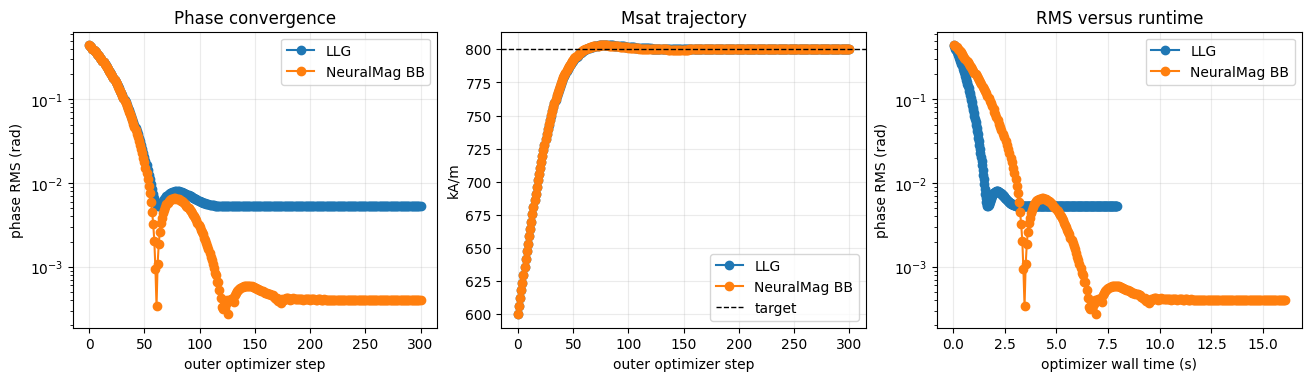

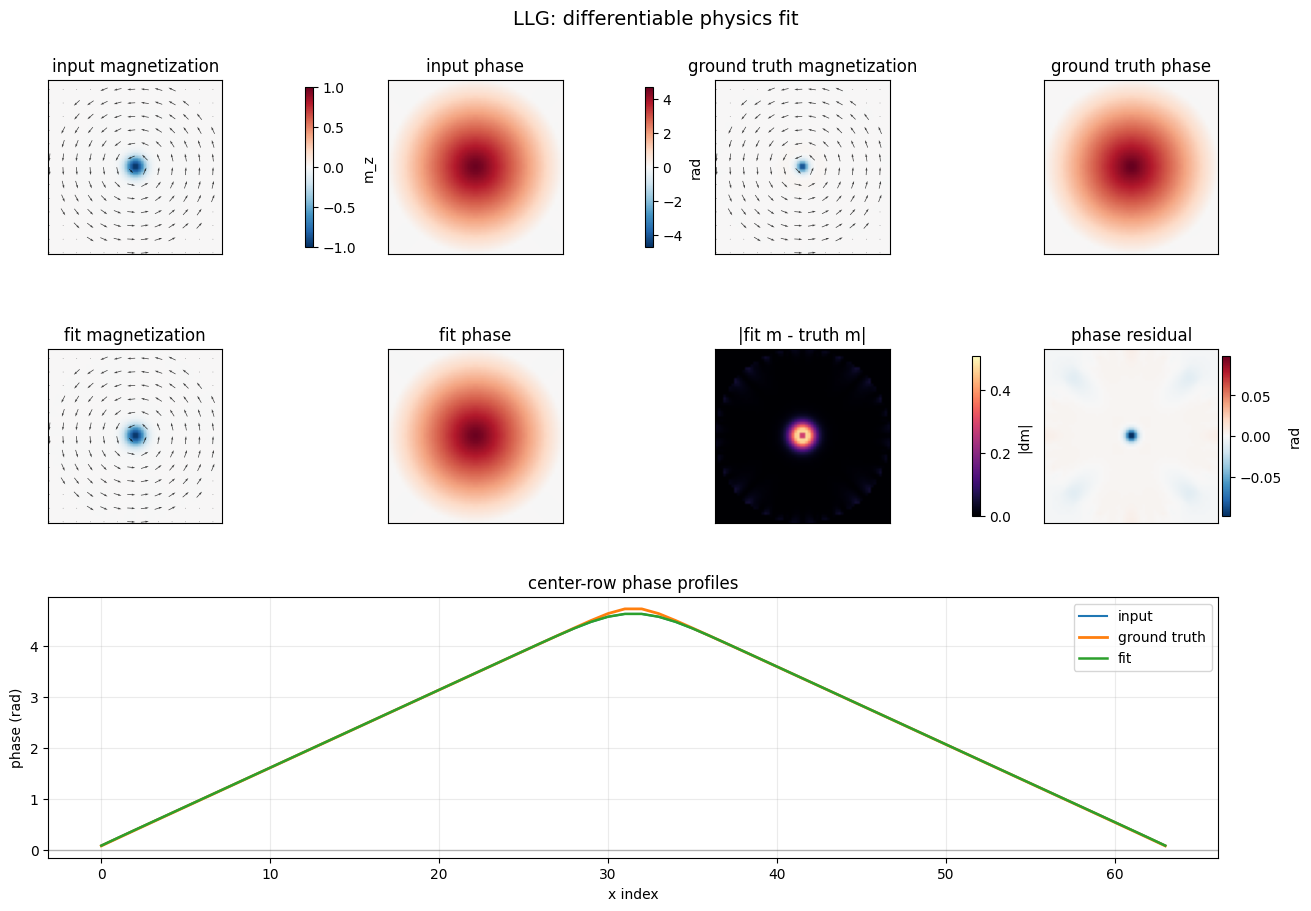

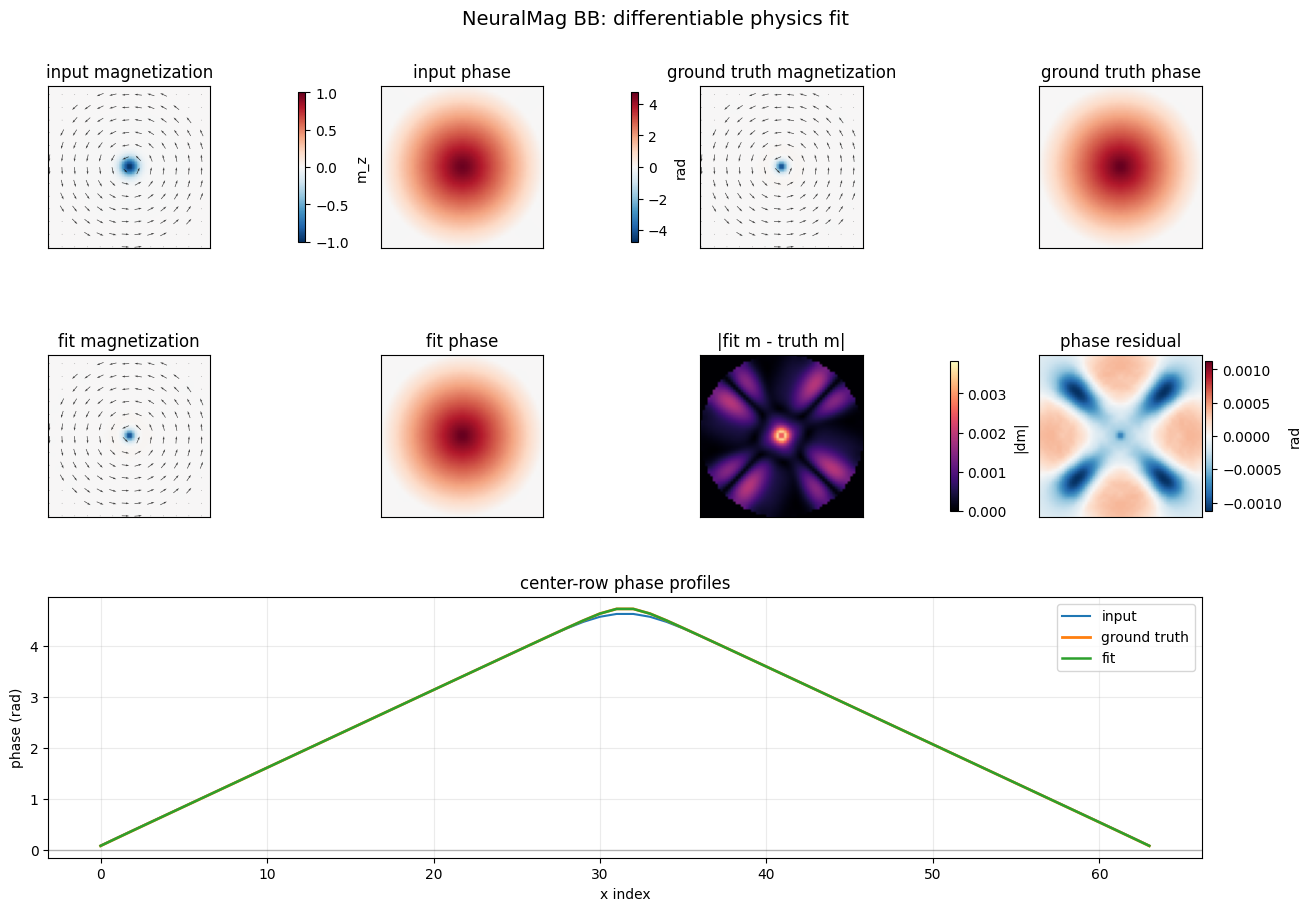

In [42]:
# Convergence and diagnostic plots for the two differentiable physics paths.

if method_comparison_results:
    fig, axs = plt.subplots(1, 3, figsize=(13, 3.7), constrained_layout=True)
    for label, result in method_comparison_results.items():
        hist = result["history"]
        steps = np.array([row["step"] for row in hist])
        rms = np.array([row["phase_rms"] for row in hist])
        msat = np.array([row["msat"] for row in hist])
        elapsed = np.array([row["elapsed_s"] for row in hist])
        axs[0].semilogy(steps, np.maximum(rms, 1e-30), marker="o", label=label)
        axs[1].plot(steps, msat / 1e3, marker="o", label=label)
        axs[2].semilogy(np.maximum(elapsed, 1e-9), np.maximum(rms, 1e-30), marker="o", label=label)

    axs[0].set_title("Phase convergence")
    axs[0].set_xlabel("outer optimizer step")
    axs[0].set_ylabel("phase RMS (rad)")
    axs[0].grid(True, alpha=0.25)
    axs[0].legend()

    axs[1].axhline(comparison_target_msat / 1e3, color="k", ls="--", lw=1.0, label="target")
    axs[1].set_title("Msat trajectory")
    axs[1].set_xlabel("outer optimizer step")
    axs[1].set_ylabel("kA/m")
    axs[1].grid(True, alpha=0.25)
    axs[1].legend()

    axs[2].set_title("RMS versus runtime")
    axs[2].set_xlabel("optimizer wall time (s)")
    axs[2].set_ylabel("phase RMS (rad)")
    axs[2].grid(True, alpha=0.25)
    axs[2].legend()
    plt.show()


def _as_np(value):
    return np.asarray(jax.device_get(value), dtype=np.float64)


def _show_m_slice(ax, m_cell, title, *, quiver_step=5):
    mid = m_cell.shape[2] // 2
    mz = m_cell[:, :, mid, 2].T
    im = ax.imshow(mz, cmap="RdBu_r", vmin=-1.0, vmax=1.0)
    x = np.arange(0, m_cell.shape[0], quiver_step)
    y = np.arange(0, m_cell.shape[1], quiver_step)
    xx, yy = np.meshgrid(x, y, indexing="xy")
    mx = m_cell[::quiver_step, ::quiver_step, mid, 0].T
    my = m_cell[::quiver_step, ::quiver_step, mid, 1].T
    ax.quiver(xx, yy, mx, my, color="k", pivot="mid", scale=22, width=0.004, alpha=0.75)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return im


def _show_phase(ax, phase, title, limit):
    im = ax.imshow(phase, cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return im


input_m_np = _as_np(comparison_input_m_cell)
target_m_np = _as_np(comparison_target_m_cell)
input_phase_np = _as_np(comparison_input_phase)
target_phase_np = _as_np(comparison_target_phase)


if "bb_inner_diagnostics" in globals() and bb_inner_diagnostics:
    fig, axs = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)
    for label, diag in bb_inner_diagnostics.items():
        max_g = _as_np(diag["max_g_history"])
        tau = _as_np(diag["tau_history"])
        inner_step = np.arange(1, len(max_g) + 1)
        axs[0].semilogy(inner_step, np.maximum(max_g, 1e-300), label=label)
        axs[1].semilogy(inner_step, np.maximum(tau, 1e-300), label=label)
    axs[0].axhline(bb_tol, color="k", ls=":", lw=1.0, label="tol")
    axs[0].set_title("BB relaxation probe")
    axs[0].set_xlabel("inner BB step")
    axs[0].set_ylabel("max |m x (m x h)|")
    axs[0].grid(True, alpha=0.25)
    axs[0].legend()
    axs[1].set_title("BB tau probe")
    axs[1].set_xlabel("inner BB step")
    axs[1].set_ylabel("tau")
    axs[1].grid(True, alpha=0.25)
    axs[1].legend()
    plt.show()

if method_comparison_results:
    for label, result in method_comparison_results.items():
        fit_m_np = _as_np(result["m_cell_final"])
        fit_phase_np = _as_np(result["phase_pred"])
        phase_resid_np = fit_phase_np - target_phase_np
        m_error_np = np.linalg.norm(fit_m_np - target_m_np, axis=-1)

        phase_lim = max(
            abs(float(input_phase_np.min())),
            abs(float(input_phase_np.max())),
            abs(float(target_phase_np.min())),
            abs(float(target_phase_np.max())),
            abs(float(fit_phase_np.min())),
            abs(float(fit_phase_np.max())),
            1e-12,
        )
        resid_lim = max(abs(float(phase_resid_np.min())), abs(float(phase_resid_np.max())), 1e-12)
        merr_lim = max(float(np.nanmax(m_error_np)), 1e-12)

        fig = plt.figure(figsize=(13, 9), constrained_layout=True)
        gs = fig.add_gridspec(3, 4)
        fig.suptitle(f"{label}: differentiable physics fit", fontsize=14)

        ax = fig.add_subplot(gs[0, 0])
        im_m = _show_m_slice(ax, input_m_np, "input magnetization")
        input_m_ax = ax

        ax = fig.add_subplot(gs[0, 1])
        im_phase_input = _show_phase(ax, input_phase_np, "input phase", phase_lim)
        input_phase_ax = ax

        ax = fig.add_subplot(gs[0, 2])
        _show_m_slice(ax, target_m_np, "ground truth magnetization")

        ax = fig.add_subplot(gs[0, 3])
        _show_phase(ax, target_phase_np, "ground truth phase", phase_lim)

        ax = fig.add_subplot(gs[1, 0])
        _show_m_slice(ax, fit_m_np, "fit magnetization")

        ax = fig.add_subplot(gs[1, 1])
        _show_phase(ax, fit_phase_np, "fit phase", phase_lim)

        ax = fig.add_subplot(gs[1, 2])
        im_err = ax.imshow(m_error_np[:, :, m_error_np.shape[2] // 2].T, cmap="magma", vmin=0.0, vmax=merr_lim)
        ax.set_title("|fit m - truth m|")
        ax.set_xticks([])
        ax.set_yticks([])
        error_ax = ax

        ax = fig.add_subplot(gs[1, 3])
        im_resid = _show_phase(ax, phase_resid_np, "phase residual", resid_lim)
        residual_ax = ax

        ax = fig.add_subplot(gs[2, :])
        x_index = np.arange(target_phase_np.shape[1])
        row = target_phase_np.shape[0] // 2
        ax.plot(x_index, input_phase_np[row], lw=1.5, label="input")
        ax.plot(x_index, target_phase_np[row], lw=2.0, label="ground truth")
        ax.plot(x_index, fit_phase_np[row], lw=1.8, label="fit")
        ax.axhline(0.0, color="k", lw=1.0, alpha=0.25)
        ax.set_title("center-row phase profiles")
        ax.set_xlabel("x index")
        ax.set_ylabel("phase (rad)")
        ax.grid(True, alpha=0.25)
        ax.legend()

        # Attach each colorbar to one contiguous panel to avoid overlap from disjoint axis groups.
        fig.colorbar(im_m, ax=[input_m_ax], fraction=0.046, pad=0.02, label="m_z")
        fig.colorbar(im_phase_input, ax=[input_phase_ax], fraction=0.046, pad=0.02, label="rad")
        fig.colorbar(im_err, ax=[error_ax], fraction=0.046, pad=0.02, label="|dm|")
        fig.colorbar(im_resid, ax=[residual_ax], fraction=0.046, pad=0.02, label="rad")
        plt.show()
